# Machine Learning : Song to Song

# **Import de librairies**

In [289]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from tqdm import tqdm
import numpy as np

# **Chargement du dataset**

In [290]:
df = pd.read_csv("/Users/beber/Documents/Cours/Wild_Code_School/Semaine_8_Visualisation_interactive_&_Pandas_approfondi/Projet_2/Projet_2_local/Datasets/df_final_corrigé.csv")

# chemin sur windows : df_spotify = pd.read_csv("/Users/beber/Documents/Cours/Wild_Code_School/Semaine_8_Visualisation_interactive_&_Pandas_approfondi/Projet_2/Projet_2_local/Datasets/df_final_corrigé.csv")

# **Tags humeur + activité**

In [291]:
df.head()

,Unnamed: 0,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,mode,speechiness,tempo,time_signature,valence,time_signature_clean,genre_group,artist_normalized,genre_simplifié,origine
0,38149.0,paula cole,i don't want to wait,5MDQNJ7SZTytJwCbWKqJDL,62,0.2980,0.410,320027,0.468,0.000012,...,Major,0.0553,177.508,4,0.4750,4.0,Autres,paula cole,jazz/blues,origine_historique
1,37124.0,mellow fellow,how was your day?,2E01rRrzaz6TuwCdm27m4m,62,0.0472,0.447,188787,0.442,0.000559,...,Minor,0.0471,159.967,4,0.7760,4.0,Autres,mellow fellow,jazz/blues,origine_historique
2,81461.0,marcell,takkan terganti,0T4t1PywlNmJGcveGH5spB,63,0.7040,0.358,241763,0.275,0.000001,...,Minor,0.0277,103.581,4,0.1170,4.0,Autres,marcell,jazz/blues,origine_historique
3,29.0,giacomo puccini,"""nessun dorma!""",74WjYdm3Lvbwnds4thYPUU,63,0.9610,0.171,180933,0.308,0.005460,...,Major,0.0456,171.798,5,0.0889,5.0,Autres,giacomo puccini,jazz/blues,origine_historique
4,37015.0,david crowder band,how he loves,6WSFMa721PvfnspCRsGOMh,63,0.0167,0.217,318693,0.466,0.000026,...,Major,0.0346,149.398,3,0.1730,3.0,Autres,david crowder band,jazz/blues,origine_historique


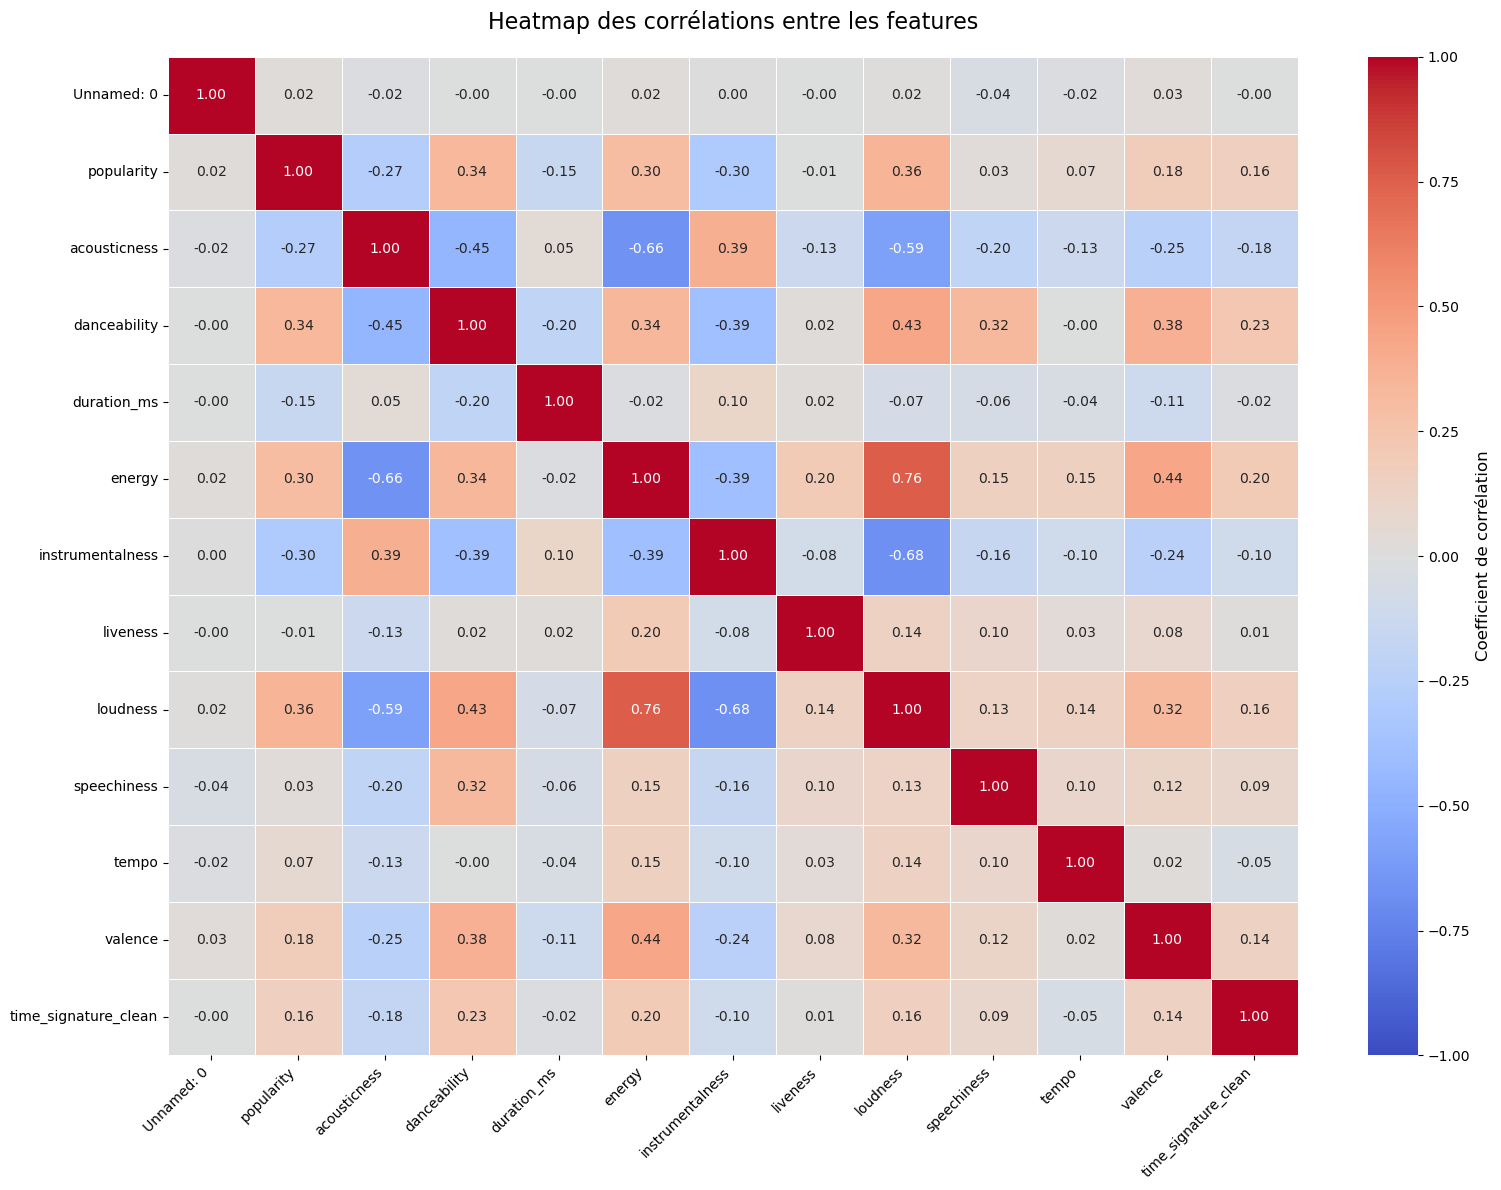

In [292]:

# Sélection uniquement des colonnes numériques pour la corrélation
# Cela exclut les colonnes de texte qui ne peuvent pas être corrélées numériquement
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Calcul de la matrice de corrélation
# La méthode .corr() calcule les coefficients de corrélation de Pearson par défaut
correlation_matrix = df_numeric.corr()

# Configuration de la figure matplotlib avec une taille appropriée
plt.figure(figsize=(16, 12))  # Ajustez la taille selon le nombre de variables

# Création de la heatmap avec seaborn
# vmin et vmax définissent l'échelle de couleurs (typiquement -1 à 1 pour des corrélations)
# annot=True affiche les valeurs de corrélation dans chaque cellule
# cmap définit la palette de couleurs (ici 'coolwarm' montre les corrélations négatives en bleu et positives en rouge)
# fmt='.2f' limite l'affichage à 2 décimales
# linewidths ajoute une fine ligne blanche entre les cellules pour améliorer la lisibilité
heatmap = sns.heatmap(correlation_matrix, 
                      annot=True,  # Afficher les valeurs
                      fmt='.2f',  # Format à 2 décimales
                      cmap='coolwarm',  # Palette de couleurs
                      linewidths=0.5,  # Lignes blanches entre les cellules
                      vmin=-1,  # Valeur minimale de l'échelle
                      vmax=1)  # Valeur maximale de l'échelle

# Ajout de titres et ajustements
plt.title('Heatmap des corrélations entre les features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotation des étiquettes x pour éviter le chevauchement
plt.yticks(fontsize=10)

# Ajout d'une barre de couleur qui explique l'échelle
cbar = heatmap.collections[0].colorbar
cbar.ax.set_ylabel('Coefficient de corrélation', fontsize=12)

# Ajustement automatique pour que tout soit visible
plt.tight_layout()

# Affichage de la heatmap
plt.show()

# Si vous souhaitez enregistrer l'image
# plt.savefig('heatmap_correlation.png', dpi=300, bbox_inches='tight')


In [293]:
# Corrélations :

# HUMEUR

    # Valence :
        # Valence/energy : 0,44

    # acoustisness :
        # acoustisness/energy : -0,66
        # acoustiness/loudness : -0,59

    # loudness :
        #loudness/acoustisness : -0,59
        #loudness/energy : 0.76 
        #loudness/instrumentalness : -0,68

# ACTIVITE

    # danceabily:
        # danceabilty/acoustisness : -0,45
        # danceabilty/loudness : 0,43

    # energy :
        #energy/acoustisness : -0,66
        #energy/loudness : 0,76
        #energy/valence : 0,44

    #instrumentalness :
        #instrumentalness/loudness : -0,68
    
    #tempo : 
        #tempo/energy : 0,15



# TOP corrélation : 
    #loudness/energy : 0.76
    #energy/loudness : 0,76
    #loudness/instrumentalness : -0,68
    #instrumentalness/loudness : -0,68
    # acoustiness/loudness : -0,59
    #loudness/acoustisness : -0,59

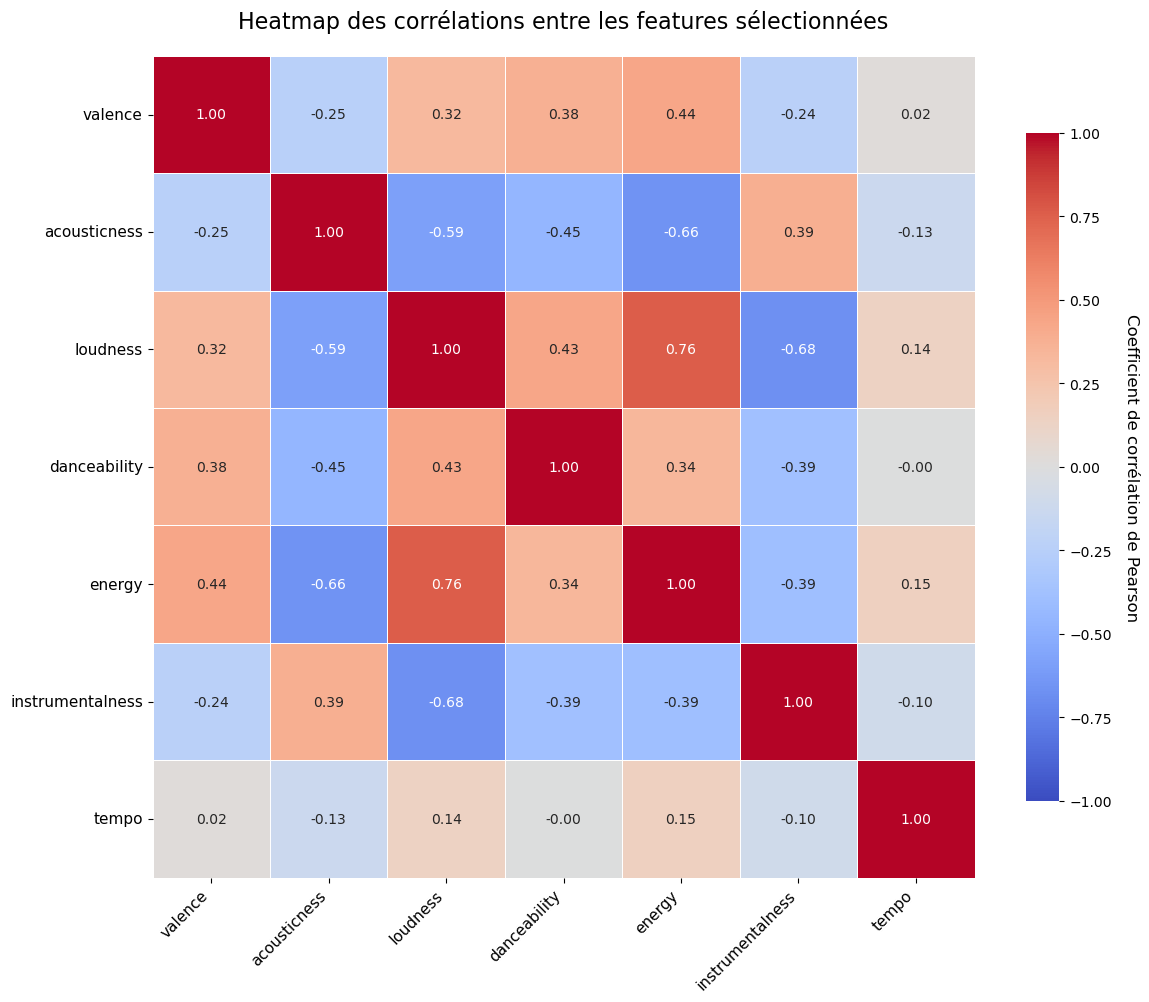

=== ANALYSE DES CORRÉLATIONS ===
Nombre de features analysées : 7
Taille de l'échantillon : 4896 observations

=== TOP 5 DES CORRÉLATIONS LES PLUS FORTES ===
energy <-> loudness: 0.764
instrumentalness <-> loudness: -0.678
energy <-> acousticness: -0.664
loudness <-> acousticness: -0.592
danceability <-> acousticness: -0.454

=== CORRÉLATIONS FAIBLES (|r| < 0.3) ===
Nombre de paires faiblement corrélées : 8
acousticness <-> valence: -0.250
instrumentalness <-> valence: -0.237
tempo <-> energy: 0.152
tempo <-> loudness: 0.140
tempo <-> acousticness: -0.131
tempo <-> instrumentalness: -0.100
tempo <-> valence: 0.019
tempo <-> danceability: -0.003


In [294]:
# Importation des bibliothèques nécessaires
import pandas as pd  # Pour la manipulation des DataFrames
import numpy as np  # Pour les opérations numériques
import matplotlib.pyplot as plt  # Pour la création de graphiques
import seaborn as sns  # Pour les visualisations statistiques avancées


# Définition des colonnes à conserver pour l'analyse de corrélation
# Liste des features musicales sélectionnées (je corrige "acoustisness" en "acousticness")
selected_features = [
    'valence',         # Mesure de la positivité émotionnelle de la musique (0.0 à 1.0)
    'acousticness',    # Mesure du caractère acoustique de la musique (0.0 à 1.0)
    'loudness',        # Volume général de la piste en décibels (dB)
    'danceability',    # Mesure de la facilité à danser sur cette musique (0.0 à 1.0)
    'energy',          # Mesure de l'intensité et de la puissance perçue (0.0 à 1.0)
    'instrumentalness', # Probabilité que la piste soit instrumentale (0.0 à 1.0)
    'tempo'            # Tempo estimé de la piste en battements par minute (BPM)
]

# Sélection des colonnes spécifiées dans le DataFrame
# Cette opération crée un nouveau DataFrame avec seulement les colonnes voulues
df_selected = df[selected_features].copy()

# Suppression des lignes contenant des valeurs manquantes
# dropna() enlève toutes les lignes qui ont au moins une valeur NaN
# Ceci garantit que le calcul de corrélation fonctionne correctement
df_selected = df_selected.dropna()

# Calcul de la matrice de corrélation de Pearson
# corr() calcule les coefficients de corrélation entre toutes les paires de variables
# Par défaut, utilise la méthode de Pearson qui mesure les relations linéaires
correlation_matrix = df_selected.corr()

# Configuration de la taille de la figure matplotlib
# figsize=(12, 10) définit la largeur et hauteur en pouces
# Une taille adaptée pour 7 variables permet une bonne lisibilité
plt.figure(figsize=(12, 10))

# Création de la heatmap avec seaborn
# sns.heatmap() crée une carte de chaleur des corrélations
heatmap = sns.heatmap(
    correlation_matrix,    # Données à visualiser (matrice de corrélation)
    annot=True,           # annot=True affiche les valeurs numériques dans chaque cellule
    fmt='.2f',            # fmt='.2f' formate les nombres à 2 décimales
    cmap='coolwarm',      # Palette de couleurs : bleu pour négatif, rouge pour positif
    linewidths=0.5,       # Largeur des lignes séparant les cellules (en points)
    square=True,          # square=True force les cellules à être carrées
    vmin=-1,              # Valeur minimale de l'échelle de couleurs
    vmax=1,               # Valeur maximale de l'échelle de couleurs
    center=0,             # center=0 centre la palette de couleurs sur zéro
    cbar_kws={'shrink': 0.8}  # Paramètres de la barre de couleur (réduction à 80%)
)

# Configuration du titre principal du graphique
# title() ajoute un titre avec une police de taille 16 et un espacement de 20 points
plt.title('Heatmap des corrélations entre les features sélectionnées', 
          fontsize=16, pad=20)

# Rotation des étiquettes de l'axe x pour éviter le chevauchement
# xticks() configure l'affichage des étiquettes de l'axe x
# rotation=45 fait tourner les labels de 45 degrés
# ha='right' aligne horizontalement les labels à droite
plt.xticks(rotation=45, ha='right', fontsize=11)

# Configuration des étiquettes de l'axe y
# yticks() configure l'affichage des étiquettes de l'axe y
plt.yticks(fontsize=11, rotation=0)

# Configuration de la barre de couleur (colorbar)
# Récupération de l'objet colorbar pour le personnaliser
cbar = heatmap.collections[0].colorbar
# Ajout d'un label explicatif sur la barre de couleur
cbar.ax.set_ylabel('Coefficient de corrélation de Pearson', 
                   fontsize=12, rotation=270, labelpad=20)

# Ajustement automatique de la mise en page
# tight_layout() optimise l'espacement pour éviter que les éléments se chevauchent
plt.tight_layout()

# Affichage du graphique à l'écran
# show() rend le graphique visible dans l'interface utilisateur
plt.show()

# Option pour sauvegarder le graphique (décommentez si nécessaire)
# plt.savefig('heatmap_features_selected.png', dpi=300, bbox_inches='tight')

# Affichage des statistiques descriptives de la matrice de corrélation
print("=== ANALYSE DES CORRÉLATIONS ===")
print(f"Nombre de features analysées : {len(selected_features)}")
print(f"Taille de l'échantillon : {len(df_selected)} observations")

# Identification des corrélations les plus fortes (en valeur absolue)
# np.triu() crée un masque triangulaire supérieur pour éviter les doublons
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
# Application du masque pour ne garder que la partie triangulaire inférieure
correlation_matrix_masked = correlation_matrix.mask(mask)

# Conversion en format long pour faciliter l'analyse
# stack() convertit la matrice en série avec index multi-niveau
correlation_pairs = correlation_matrix_masked.stack().reset_index()
correlation_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

# Tri par valeur absolue de corrélation (plus fortes corrélations en premier)
correlation_pairs['Abs_Correlation'] = correlation_pairs['Correlation'].abs()
correlation_pairs_sorted = correlation_pairs.sort_values('Abs_Correlation', 
                                                        ascending=False)

print("\n=== TOP 5 DES CORRÉLATIONS LES PLUS FORTES ===")
# Affichage des 5 corrélations les plus importantes
for i, row in correlation_pairs_sorted.head().iterrows():
    print(f"{row['Feature1']} <-> {row['Feature2']}: {row['Correlation']:.3f}")

print("\n=== CORRÉLATIONS FAIBLES (|r| < 0.3) ===")
# Identification des paires avec corrélations faibles
weak_correlations = correlation_pairs_sorted[
    correlation_pairs_sorted['Abs_Correlation'] < 0.3
]
print(f"Nombre de paires faiblement corrélées : {len(weak_correlations)}")
for i, row in weak_correlations.iterrows():
    print(f"{row['Feature1']} <-> {row['Feature2']}: {row['Correlation']:.3f}")


In [295]:
def creer_tags_manuel(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute deux colonnes :
      - tags_humeur  : #joyeux, #triste, #energique, #calme
      - tags_activité: #dance/#fête, #concentration/#travail,
                       #sport/#cardio, #meditation/#yoga
    """
    # Définition du tag d’humeur
    def tag_humeur(valence, acousticness, loudness):
        if valence >= 0.75:
            return "#joyeux"
        if valence < 0.25:
            return "#triste"
        if loudness >= -20 or acousticness < 0.3:
            return "#energique"
        return "#calme"

    # Définition du tag d’activité
    def tag_activite(danceability, energy, tempo):
        if danceability >= 0.5:
            return "#dance/#fête"
        if energy >= 0.6 or tempo >= 110:
            return "#sport/#cardio"
        if energy >= 0.3:
            return "#concentration/#travail"
        return "#meditation/#yoga"

    # Application ligne par ligne
    df["tags_humeur"] = df.apply(
        lambda r: tag_humeur(r["valence"], r["acousticness"], r["loudness"]), axis=1
    )
    df["tags_activité"] = df.apply(
        lambda r: tag_activite(r["danceability"], r["energy"], r["tempo"]), axis=1
    )

    # Vérification des tags uniques et comptages
    uniques_humeur = df["tags_humeur"].unique().tolist()
    compte_humeur = df["tags_humeur"].value_counts().reset_index()
    compte_humeur.columns = ["tag_humeur", "occurrences"]

    uniques_activite = df["tags_activité"].unique().tolist()
    compte_activite = df["tags_activité"].value_counts().reset_index()
    compte_activite.columns = ["tag_activité", "occurrences"]

    # Affichage des vérifications
    print("Tags d’humeur uniques :", uniques_humeur)
    print("\nRépartition des tags d’humeur :")
    print(compte_humeur)

    print("\nTags d’activité uniques :", uniques_activite)
    print("\nRépartition des tags d’activité :")
    print(compte_activite)

    return df


df_tagged = creer_tags_manuel(df)
df_tagged


Tags d’humeur uniques : ['#energique', '#joyeux', '#triste', '#calme']

Répartition des tags d’humeur :
   tag_humeur  occurrences
0  #energique         3153
1     #triste         1200
2     #joyeux          522
3      #calme           21

Tags d’activité uniques : ['#sport/#cardio', '#meditation/#yoga', '#dance/#fête', '#concentration/#travail']

Répartition des tags d’activité :
              tag_activité  occurrences
0             #dance/#fête         3860
1           #sport/#cardio          631
2  #concentration/#travail          210
3        #meditation/#yoga          195


,Unnamed: 0,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,tempo,time_signature,valence,time_signature_clean,genre_group,artist_normalized,genre_simplifié,origine,tags_humeur,tags_activité
0,38149.0,paula cole,i don't want to wait,5MDQNJ7SZTytJwCbWKqJDL,62,0.2980,0.410,320027,0.468,0.000012,...,177.508,4,0.4750,4.0,Autres,paula cole,jazz/blues,origine_historique,#energique,#sport/#cardio
1,37124.0,mellow fellow,how was your day?,2E01rRrzaz6TuwCdm27m4m,62,0.0472,0.447,188787,0.442,0.000559,...,159.967,4,0.7760,4.0,Autres,mellow fellow,jazz/blues,origine_historique,#joyeux,#sport/#cardio
2,81461.0,marcell,takkan terganti,0T4t1PywlNmJGcveGH5spB,63,0.7040,0.358,241763,0.275,0.000001,...,103.581,4,0.1170,4.0,Autres,marcell,jazz/blues,origine_historique,#triste,#meditation/#yoga
3,29.0,giacomo puccini,"""nessun dorma!""",74WjYdm3Lvbwnds4thYPUU,63,0.9610,0.171,180933,0.308,0.005460,...,171.798,5,0.0889,5.0,Autres,giacomo puccini,jazz/blues,origine_historique,#triste,#sport/#cardio
4,37015.0,david crowder band,how he loves,6WSFMa721PvfnspCRsGOMh,63,0.0167,0.217,318693,0.466,0.000026,...,149.398,3,0.1730,3.0,Autres,david crowder band,jazz/blues,origine_historique,#triste,#sport/#cardio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4891,9607.0,fergie,big girls don't cry (personal),3Q4WeJmzxuDpzMu9QjQqbM,75,0.2390,0.712,268120,0.647,0.000000,...,113.116,4,0.2920,4.0,Autres,fergie,électro/dance,origine_historique,#energique,#dance/#fête
4892,37970.0,cardi b,i do (feat. sza),1f5PNhkNgUpvDEeZfcIlO1,75,0.2700,0.886,200205,0.473,0.000026,...,135.065,4,0.4380,4.0,Autres,cardi b,électro/dance,origine_historique,#energique,#dance/#fête
4893,38790.0,g-eazy,i mean it,6jmTHeoWvBaSrwWttr8Xvu,75,0.1250,0.712,236480,0.562,0.000000,...,140.000,4,0.1420,4.0,Autres,g-eazy,électro/dance,origine_historique,#triste,#dance/#fête
4894,64338.0,shakira,perro fiel (feat. nicky jam),70lnL3QaSOIIyMa2X9aVRL,75,0.1870,0.750,195213,0.760,0.000000,...,183.817,4,0.8930,4.0,Autres,shakira,électro/dance,origine_historique,#joyeux,#dance/#fête


In [296]:
df_tagged.loc[:, ["artist_name", "track_name", "track_id", "genre_simplifié"]]


,artist_name,track_name,track_id,genre_simplifié
0,paula cole,i don't want to wait,5MDQNJ7SZTytJwCbWKqJDL,jazz/blues
1,mellow fellow,how was your day?,2E01rRrzaz6TuwCdm27m4m,jazz/blues
2,marcell,takkan terganti,0T4t1PywlNmJGcveGH5spB,jazz/blues
3,giacomo puccini,"""nessun dorma!""",74WjYdm3Lvbwnds4thYPUU,jazz/blues
4,david crowder band,how he loves,6WSFMa721PvfnspCRsGOMh,jazz/blues
...,...,...,...,...
4891,fergie,big girls don't cry (personal),3Q4WeJmzxuDpzMu9QjQqbM,électro/dance
4892,cardi b,i do (feat. sza),1f5PNhkNgUpvDEeZfcIlO1,électro/dance
4893,g-eazy,i mean it,6jmTHeoWvBaSrwWttr8Xvu,électro/dance
4894,shakira,perro fiel (feat. nicky jam),70lnL3QaSOIIyMa2X9aVRL,électro/dance


# Machine Learning

## Import des bibliothèques de ML

In [297]:
# Importation de la fonction pour diviser les données en ensembles d'entraînement et de test
from sklearn.model_selection import train_test_split

# Importation de l'encodeur de labels pour transformer les variables cibles catégorielles en entiers
from sklearn.preprocessing import LabelEncoder

# Importation du modèle KNN pour la classification supervisée (prédiction de classes)
from sklearn.neighbors import KNeighborsClassifier

# Importation du modèle KNN pour l'apprentissage non supervisé (recherche de voisins les plus proches sans cible)
from sklearn.neighbors import NearestNeighbors

# Importation de plusieurs métriques d'évaluation :
# - mean_squared_error : erreur quadratique moyenne (surtout pour la régression)
# - r2_score : coefficient de détermination (pour la régression)
# - accuracy_score : taux de bonnes classifications (pour la classification)
# - classification_report : rapport détaillé sur la classification (précision, rappel, f1-score)
# - confusion_matrix : matrice de confusion (pour visualiser les erreurs de classification)
# - ConfusionMatrixDisplay : outil pour afficher graphiquement la matrice de confusion
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Importation de l'outil de standardisation des données (mise à l'échelle des features pour améliorer les performances des modèles)
from sklearn.preprocessing import StandardScaler

# Importation de l'outil Pipeline pour chaîner plusieurs étapes de prétraitement et de modélisation dans un même objet
from sklearn.pipeline import Pipeline

# Importation du module warnings pour gérer (filtrer, ignorer) les messages d'avertissement lors de l'exécution du code
import warnings


## ML supervisé : KNN (k=5, test_size=0.25, metric='euclidean')

In [298]:
# === RECOMMANDATIONS POUR LE MODÈLE MOODIFY ===

# Variables principales : valence, energy, danceability
# Variables secondaires : acousticness, tempo, loudness

In [299]:
df["genre_simplifié"].unique()

array(['jazz/blues', 'variété française', 'rap', 'classique/opéra',
       'rock/indie', 'pop', 'électro/dance'], dtype=object)

In [300]:
df["genre_simplifié"].nunique()

7

In [301]:
# Sélectionne toutes les lignes du DataFrame 'df' et uniquement les colonnes spécifiées :
# - 'valence' : mesure la positivité de la chanson (score de 0 à 1)
# - 'energy' : mesure l'intensité et l'activité perçues (score de 0 à 1)
# - 'danceability' : mesure à quel point un morceau est dansant (score de 0 à 1)
# - 'acousticness' : probabilité qu'un morceau soit acoustique (score de 0 à 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume perçu de la chanson (en décibels, dB)
df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness', 'instrumentalness']]


,valence,energy,danceability,acousticness,tempo,loudness,instrumentalness
0,0.4750,0.468,0.410,0.2980,177.508,-8.177,0.000012
1,0.7760,0.442,0.447,0.0472,159.967,-11.221,0.000559
2,0.1170,0.275,0.358,0.7040,103.581,-8.324,0.000001
3,0.0889,0.308,0.171,0.9610,171.798,-12.383,0.005460
4,0.1730,0.466,0.217,0.0167,149.398,-6.156,0.000026
...,...,...,...,...,...,...,...
4891,0.2920,0.647,0.712,0.2390,113.116,-4.277,0.000000
4892,0.4380,0.473,0.886,0.2700,135.065,-7.338,0.000026
4893,0.1420,0.562,0.712,0.1250,140.000,-6.008,0.000000
4894,0.8930,0.760,0.750,0.1870,183.817,-4.836,0.000000


In [302]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")



--- Classification (KNeighborsClassifier pour prédire 'genre') ---


In [303]:
# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=5) applique l'algorithme KNN pour la classification
#    - n_neighbors=5 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=5) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
    ])

In [304]:
# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


In [305]:
# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre_simplifié' du DataFrame 'df'
y_class_KNN = df['genre_simplifié']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)

In [306]:
# Affiche la liste des genres et leur numéro attribué
for idx, genre in enumerate(le.classes_):
    print(f"{genre} : {idx}")


classique/opéra : 0
jazz/blues : 1
pop : 2
rap : 3
rock/indie : 4
variété française : 5
électro/dance : 6


In [307]:
genre = le.classes_
genre


array(['classique/opéra', 'jazz/blues', 'pop', 'rap', 'rock/indie',
       'variété française', 'électro/dance'], dtype=object)

In [308]:
# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


In [309]:
# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


In [310]:
# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: 0.7061
Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: 0.5918


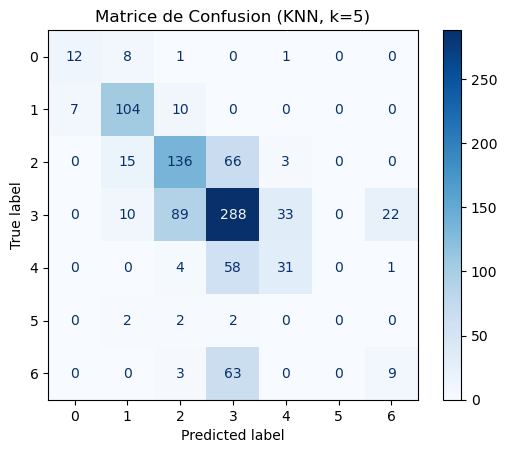

In [311]:
# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage pour la matrice de confusion
# ConfusionMatrixDisplay permet de personnaliser et d'afficher facilement la matrice
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)

# Affichage graphique de la matrice de confusion avec une palette de couleurs bleues pour une meilleure lisibilité
disp_knn.plot(cmap='Blues')

# Ajout d'un titre à la figure pour préciser le modèle et la valeur de k utilisée
plt.title("Matrice de Confusion (KNN, k=5)")

# Affichage de la figure à l'écran
plt.show()


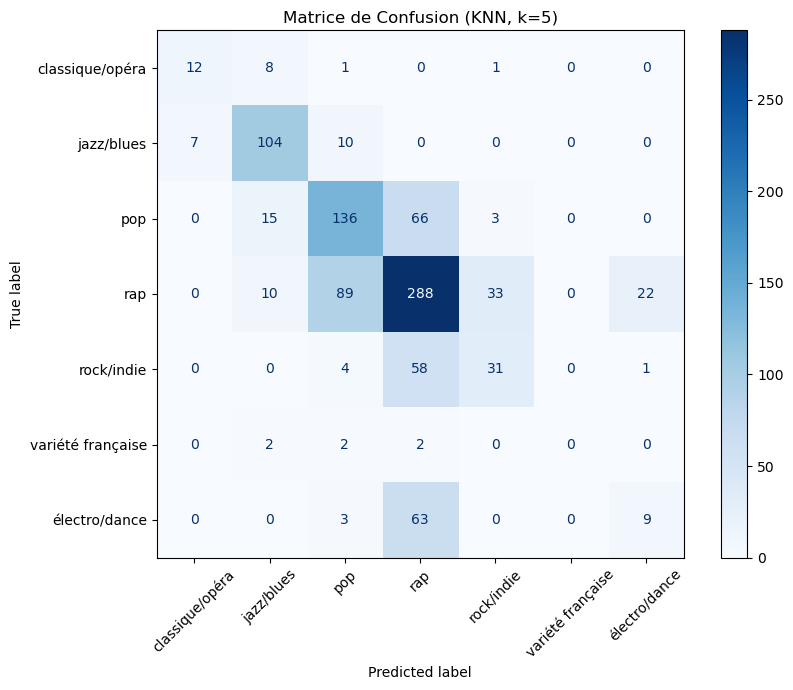

In [312]:
# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=5)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


In [313]:
# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))



Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.63      0.55      0.59        22
       jazz/blues       0.75      0.86      0.80       121
              pop       0.56      0.62      0.58       220
              rap       0.60      0.65      0.63       442
       rock/indie       0.46      0.33      0.38        94
variété française       0.00      0.00      0.00         6
    électro/dance       0.28      0.12      0.17        75

         accuracy                           0.59       980
        macro avg       0.47      0.45      0.45       980
     weighted avg       0.57      0.59      0.58       980



c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## ML supervisé : KNN (k=7, test_size=0.25, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble d'entraînement: 0.6936
Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble de test: 0.5969


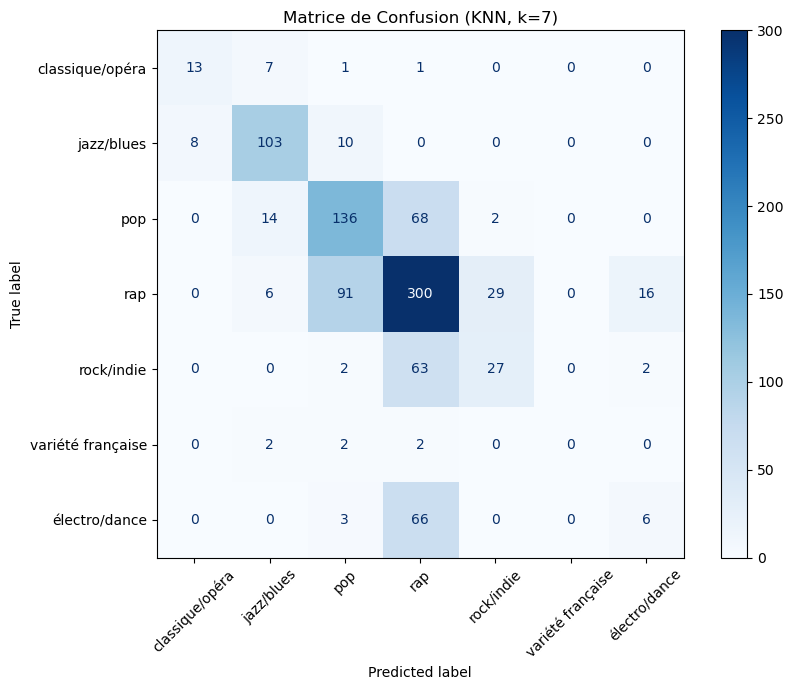


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.62      0.59      0.60        22
       jazz/blues       0.78      0.85      0.81       121
              pop       0.56      0.62      0.58       220
              rap       0.60      0.68      0.64       442
       rock/indie       0.47      0.29      0.36        94
variété française       0.00      0.00      0.00         6
    électro/dance       0.25      0.08      0.12        75

         accuracy                           0.60       980
        macro avg       0.47      0.44      0.45       980
     weighted avg       0.57      0.60      0.58       980



c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [314]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=7) applique l'algorithme KNN pour la classification
#    - n_neighbors=7 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=7) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre_simplifié' du DataFrame 'df'
y_class_KNN = df['genre_simplifié']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=7) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=7)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## ML supervisé : KNN (k=10, test_size=0.25, metric='euclidean')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble d'entraînement: 0.6864
Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble de test: 0.6224


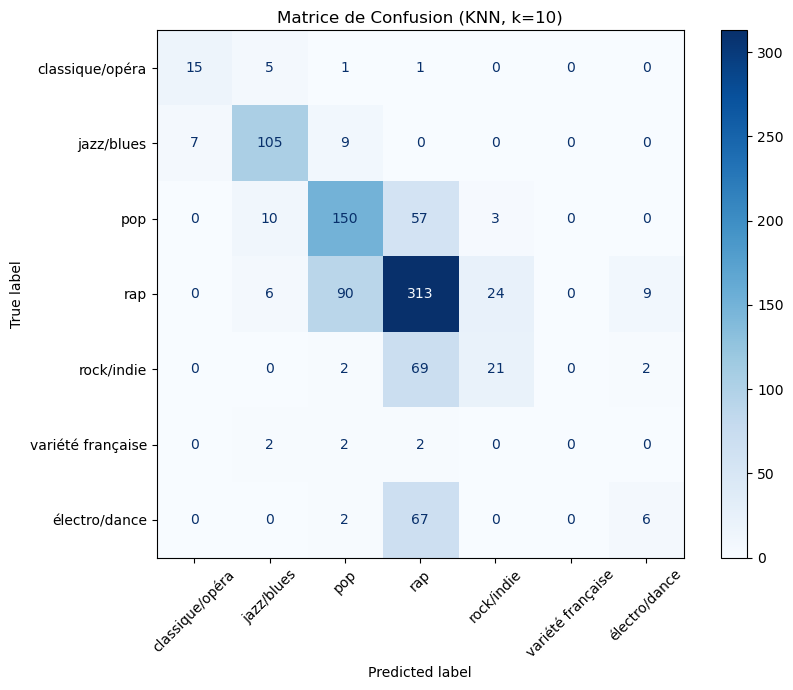


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.68      0.68      0.68        22
       jazz/blues       0.82      0.87      0.84       121
              pop       0.59      0.68      0.63       220
              rap       0.61      0.71      0.66       442
       rock/indie       0.44      0.22      0.30        94
variété française       0.00      0.00      0.00         6
    électro/dance       0.35      0.08      0.13        75

         accuracy                           0.62       980
        macro avg       0.50      0.46      0.46       980
     weighted avg       0.59      0.62      0.60       980



c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [315]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=10) applique l'algorithme KNN pour la classification
#    - n_neighbors=10 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=10) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre_simplifié' du DataFrame 'df'
y_class_KNN = df['genre_simplifié']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=10) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=10)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))




## Tableau comparatif : ML supervisé KNN (metric = 'eucldean')

In [ ]:
# Fonction pour afficher le tableau comparatif des métriques
def display_comparison_table(results_df):
    """
    Affiche un tableau comparatif formaté des métriques pour différentes valeurs de k
    
    Arguments:
    - results_df : DataFrame contenant les métriques pour chaque valeur de k
    
    Fonctionnement :
    - Formate les valeurs numériques avec 4 décimales pour une meilleure lisibilité
    - Affiche le tableau avec des séparateurs visuels pour la clarté
    """
    # Formatage des valeurs numériques avec 4 décimales
    formatted_df = results_df.round(4)
    
    # Affichage du tableau comparatif avec mise en forme
    print("\n" + "="*80)
    print("TABLEAU COMPARATIF DES MÉTRIQUES D'ÉVALUATION KNN")
    print("="*80)
    print(formatted_df.to_string(index=False))
    print("="*80)
    
    # Analyse des résultats pour aider à l'interprétation
    print("\nANALYSE DES RÉSULTATS :")
    print("-" * 30)
    
    # Identification de la meilleure valeur de k pour chaque métrique
    best_accuracy = formatted_df.loc[formatted_df['accuracy_test'].idxmax()]
    best_precision = formatted_df.loc[formatted_df['precision'].idxmax()]
    best_recall = formatted_df.loc[formatted_df['recall'].idxmax()]
    best_f1 = formatted_df.loc[formatted_df['f1_score'].idxmax()]
    
    print(f"Meilleure accuracy (test) : k={best_accuracy['k']} avec {best_accuracy['accuracy_test']:.4f}")
    print(f"Meilleure precision : k={best_precision['k']} avec {best_precision['precision']:.4f}")
    print(f"Meilleur recall : k={best_recall['k']} avec {best_recall['recall']:.4f}")
    print(f"Meilleur F1-score : k={best_f1['k']} avec {best_f1['f1_score']:.4f}")


# Affichage du tableau comparatif final
display_comparison_table(results_df)


TABLEAU COMPARATIF DES MÉTRIQUES D'ÉVALUATION KNN
 k  accuracy_train  accuracy_test  precision  recall  f1_score
 5          0.7061         0.5918     0.5687  0.5918    0.5755
 7          0.6936         0.5969     0.5693  0.5969    0.5760
10          0.6864         0.6224     0.5944  0.6224    0.5962

ANALYSE DES RÉSULTATS :
------------------------------
Meilleure accuracy (test) : k=10.0 avec 0.6224
Meilleure precision : k=10.0 avec 0.5944
Meilleur recall : k=10.0 avec 0.6224
Meilleur F1-score : k=10.0 avec 0.5962


## ML supervisé : KNN (k=5, test_size=0.25, metric='cosine')


--- Classification (KNeighborsClassifier pour prédire 'genre') ---
Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: 0.6946
Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: 0.5857


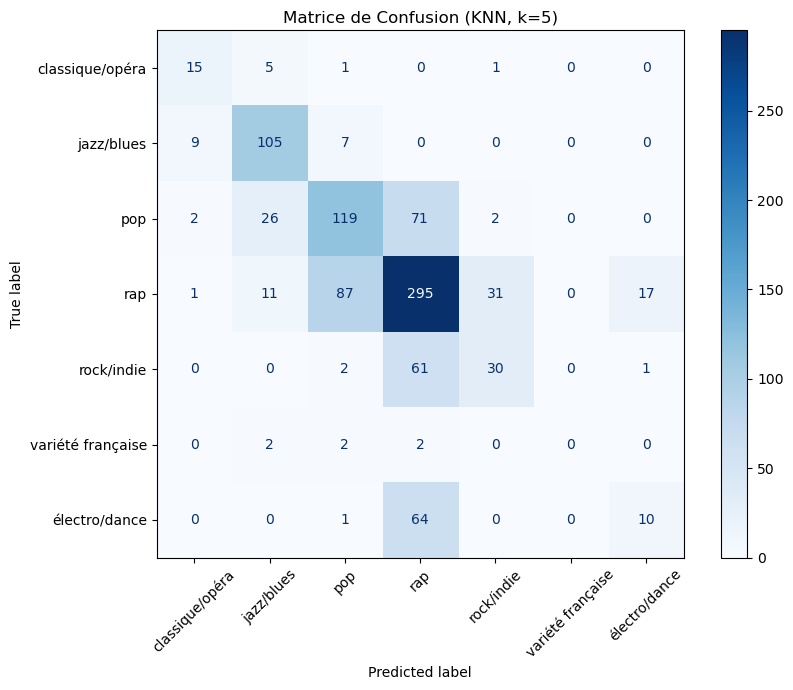


Rapport de Classification (KNN):
                   precision    recall  f1-score   support

  classique/opéra       0.56      0.68      0.61        22
       jazz/blues       0.70      0.87      0.78       121
              pop       0.54      0.54      0.54       220
              rap       0.60      0.67      0.63       442
       rock/indie       0.47      0.32      0.38        94
variété française       0.00      0.00      0.00         6
    électro/dance       0.36      0.13      0.19        75

         accuracy                           0.59       980
        macro avg       0.46      0.46      0.45       980
     weighted avg       0.56      0.59      0.57       980



c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\beber\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [319]:
# Affiche un titre pour indiquer le début de la section de classification avec KNeighborsClassifier
print("\n--- Classification (KNeighborsClassifier pour prédire 'genre') ---")


# Création d'un pipeline de machine learning pour la classification
# Le pipeline enchaîne deux étapes principales :
# 1. 'scaler' : StandardScaler() standardise les features (moyenne 0, écart-type 1)
#    - Cela est crucial pour KNN, car il se base sur des distances : toutes les features doivent être sur la même échelle.
# 2. 'classifier' : KNeighborsClassifier(n_neighbors=5) applique l'algorithme KNN pour la classification
#    - n_neighbors=5 signifie que la classe prédite sera celle la plus fréquente parmi les 5 voisins les plus proches.
#    - Ce paramètre (k=5) est un choix courant, mais il peut être optimisé via validation croisée.
pipeline_knn_clf = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=5, metric='cosine'))
    ])

# Sélection des features pour la classification avec KNN
# On extrait du DataFrame 'df' les colonnes suivantes :
# - 'valence' : mesure la positivité de la chanson (valeur entre 0 et 1)
# - 'energy' : mesure l'intensité de la chanson (valeur entre 0 et 1)
# - 'danceability' : mesure à quel point la chanson est dansante (valeur entre 0 et 1)
# - 'acousticness' : probabilité que la chanson soit acoustique (valeur entre 0 et 1)
# - 'tempo' : tempo de la chanson en battements par minute (BPM)
# - 'loudness' : volume sonore moyen de la chanson (en décibels)
# Ces colonnes sont sélectionnées car elles sont pertinentes pour caractériser et différencier les genres musicaux.
X_class_KNN = df.loc[:, ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'loudness']]


# Sélection de la variable cible (target) pour la classification
# Ici, on utilise la colonne 'genre_simplifié' du DataFrame 'df'
y_class_KNN = df['genre_simplifié']

# Instanciation de l'encodeur de labels
# LabelEncoder va transformer les genres musicaux (catégories textuelles) en entiers
le = LabelEncoder()

# Encodage de la variable cible
# Chaque genre unique est transformé en un entier unique (ex : 'pop' -> 0, 'rock' -> 1, etc.)
# Cela permet de rendre la cible compatible avec les algorithmes de classification de scikit-learn
y_class_KNN_encoded = le.fit_transform(y_class_KNN)


# Division des données en ensembles d'entraînement et de test pour la classification KNN

# On utilise train_test_split pour séparer les features (X_class_KNN) et la cible encodée (y_class_KNN_encoded)
# test_size=0.2 : 20% des données seront utilisées pour le test, 80% pour l'entraînement
# random_state=42 : fixe la graine aléatoire pour garantir la reproductibilité des résultats
# stratify=y_class_KNN_encoded : garantit que la proportion de chaque classe (genre) est respectée dans les deux ensembles,
# ce qui est crucial en cas de déséquilibre des classes

X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(
    X_class_KNN,                # Features sélectionnées pour la classification
    y_class_KNN_encoded,        # Cible encodée en entiers
    test_size=0.2,              # Pourcentage des données dans l'ensemble de test
    random_state=42,            # Graine pour la reproductibilité
    stratify=y_class_KNN_encoded # Strate sur la cible pour équilibrer les classes dans chaque ensemble
)


# Pour KNN, la méthode .fit() ne construit pas un modèle complexe :
# Elle se contente de stocker les données d'entraînement, car l'algorithme KNN va comparer les nouveaux échantillons
# directement à ces données lors de la prédiction.
pipeline_knn_clf.fit(X_train_KNN, y_train_KNN)

# La méthode .predict() du pipeline :
# - Pour chaque échantillon, calcule la distance entre cet échantillon et tous les points d'entraînement stockés.
# - Sélectionne les k voisins les plus proches (selon la distance choisie, généralement euclidienne).
# - Attribue la classe majoritaire parmi ces voisins comme prédiction.

# Prédictions sur l'ensemble d'entraînement (permet de mesurer l'overfitting)
y_pred_knn_clf_train = pipeline_knn_clf.predict(X_train_KNN)

# Prédictions sur l'ensemble de test (permet d'évaluer la généralisation du modèle)
y_pred_knn_clf_test = pipeline_knn_clf.predict(X_test_KNN)


# Calcul de l'accuracy (taux de bonnes prédictions) sur l'ensemble d'entraînement
accuracy_knn_clf_train = accuracy_score(y_train_KNN, y_pred_knn_clf_train)
# Affichage formaté de l'accuracy d'entraînement avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble d'entraînement: {accuracy_knn_clf_train:.4f}")

# Calcul de l'accuracy sur l'ensemble de test
accuracy_knn_clf_test = accuracy_score(y_test_KNN, y_pred_knn_clf_test)
# Affichage formaté de l'accuracy de test avec 4 décimales
print(f"Modèle de Classification (KNN, k=5) - Accuracy sur l'ensemble de test: {accuracy_knn_clf_test:.4f}")


# Calcul de la matrice de confusion pour le modèle KNN sur l'ensemble de test
# La matrice de confusion permet de visualiser le nombre de prédictions correctes et incorrectes pour chaque classe
cm_knn = confusion_matrix(y_test_KNN, y_pred_knn_clf_test)

# Création de l'objet d'affichage avec les noms de genres
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=genre)

# Création d'une figure plus large pour éviter le chevauchement
fig, ax = plt.subplots(figsize=(9, 7))
disp_knn.plot(cmap='Blues', ax=ax, xticks_rotation=45)  # xticks_rotation=45 incline les labels de l'axe x

plt.title("Matrice de Confusion (KNN, k=5)")
plt.tight_layout()  # Ajuste automatiquement les marges pour éviter que les labels soient coupés
plt.show()


# Affiche un titre pour séparer visuellement le rapport de classification dans la console
print("\nRapport de Classification (KNN):")

# Affiche un rapport détaillé sur les performances du modèle KNN pour chaque genre musical (classe)
# classification_report calcule et affiche les métriques suivantes pour chaque classe :
# - precision : proportion de prédictions correctes parmi toutes les prédictions positives pour cette classe
# - recall (rappel) : proportion de prédictions correctes parmi toutes les vraies instances de cette classe
# - f1-score : moyenne harmonique entre la précision et le rappel, mesure globale de la performance
# - support : nombre d'échantillons réels de chaque classe dans l'ensemble de test
# L'argument target_names=genre permet d'afficher les noms des genres au lieu des indices numériques.
# Attention : la variable 'genre' doit contenir la liste ordonnée des noms de genres correspondant à l'encodage utilisé (ex : le.classes_)
print(classification_report(y_test_KNN, y_pred_knn_clf_test, target_names=genre))


